In [1]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
from glob import glob
from itertools import chain
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input, BatchNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# Configuration for image processing and batch size
IMG_SIZE = (224, 224) 
BATCH_SIZE = 32

# List of the 14 disease labels present in the NIH dataset
LABEL_COLUMNS = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 
                 'Emphysema', 'Fibrosis', 'Infiltration', 'Mass', 'Nodule', 
                 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

2026-01-25 22:25:25.247059: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769379925.446251      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769379925.510176      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769379925.998817      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769379925.998872      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769379925.998875      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# Load the main dataset index file
all_xray_df = pd.read_csv('/kaggle/input/data/Data_Entry_2017.csv')

# Map image filenames to their full system paths
all_image_paths = {os.path.basename(x): x for x in 
                   glob(os.path.join('/kaggle/input/data/images*', '*', '*.png'))}

print(f'Scans found: {len(all_image_paths)}, Total Headers: {all_xray_df.shape[0]}')
all_xray_df['path'] = all_xray_df['Image Index'].map(all_image_paths.get)

# Data Cleaning: Fix patient age format and clip outliers
all_xray_df['Patient Age'] = all_xray_df['Patient Age'].map(
    lambda x: int(str(x)[:-1]) if isinstance(x, str) and not str(x).isdigit() else int(x)
)
all_xray_df['Patient Age'] = all_xray_df['Patient Age'].clip(upper=100)

# Multi-label encoding: Remove 'No Finding' and create binary columns for each label
all_xray_df['Finding Labels'] = all_xray_df['Finding Labels'].map(lambda x: x.replace('No Finding', ''))
for c_label in LABEL_COLUMNS:
    all_xray_df[c_label] = all_xray_df['Finding Labels'].map(lambda finding: 1.0 if c_label in finding else 0)

# Keep only necessary columns to save memory
all_xray_df = all_xray_df[['path', 'Finding Labels'] + LABEL_COLUMNS]
all_xray_df.sample(3)

Scans found: 112120, Total Headers: 112120


,path,Finding Labels,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
17787,/kaggle/input/data/images_003/images/00004808_...,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
98173,/kaggle/input/data/images_011/images/00025924_...,Emphysema,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
104268,/kaggle/input/data/images_011/images/00027854_...,Infiltration,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Apply weighted sampling to focus on images with diseases (Weighted Resampling)
sample_weights = all_xray_df['Finding Labels'].map(lambda x: len(x.split('|')) if len(x)>0 else 0).values + 0.05
sample_weights /= sample_weights.sum()

# Resample 40,000 images for training and validation
all_xray_df = all_xray_df.sample(40000, weights=sample_weights, random_state=42).reset_index(drop=True)

# Split data into training (80%) and validation (20%)
train_df, valid_df = train_test_split(all_xray_df, test_size=0.20, random_state=42)

print(f'Train size: {len(train_df)}, Validation size: {len(valid_df)}')

Train size: 32000, Validation size: 8000


In [14]:
# Augmentation for training
train_idg = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.01,
    zoom_range=0.15,
    samplewise_center=True,
    samplewise_std_normalization=True
)

# Normalization for validation
valid_idg = ImageDataGenerator(
    rescale=1./255,
    samplewise_center=True,
    samplewise_std_normalization=True
)

train_gen = train_idg.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col=LABEL_COLUMNS,
    class_mode='raw',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

valid_gen = valid_idg.flow_from_dataframe(
    dataframe=valid_df,
    x_col='path',
    y_col=LABEL_COLUMNS,
    class_mode='raw',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


Found 32000 validated image filenames.
Found 8000 validated image filenames.


In [15]:
def build_model():
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = True # Fine-tuning enabled
    
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    
    predictions = Dense(len(LABEL_COLUMNS), activation='sigmoid')(x)
    
    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['binary_accuracy', tf.keras.metrics.AUC(multi_label=True, name='auc')]
    )
    return model

model = build_model()

In [16]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,702,093 (29.38 MB)

 Trainable params: 7,615,885 (29.05 MB)

 Non-trainable params: 86,208 (336.75 KB)

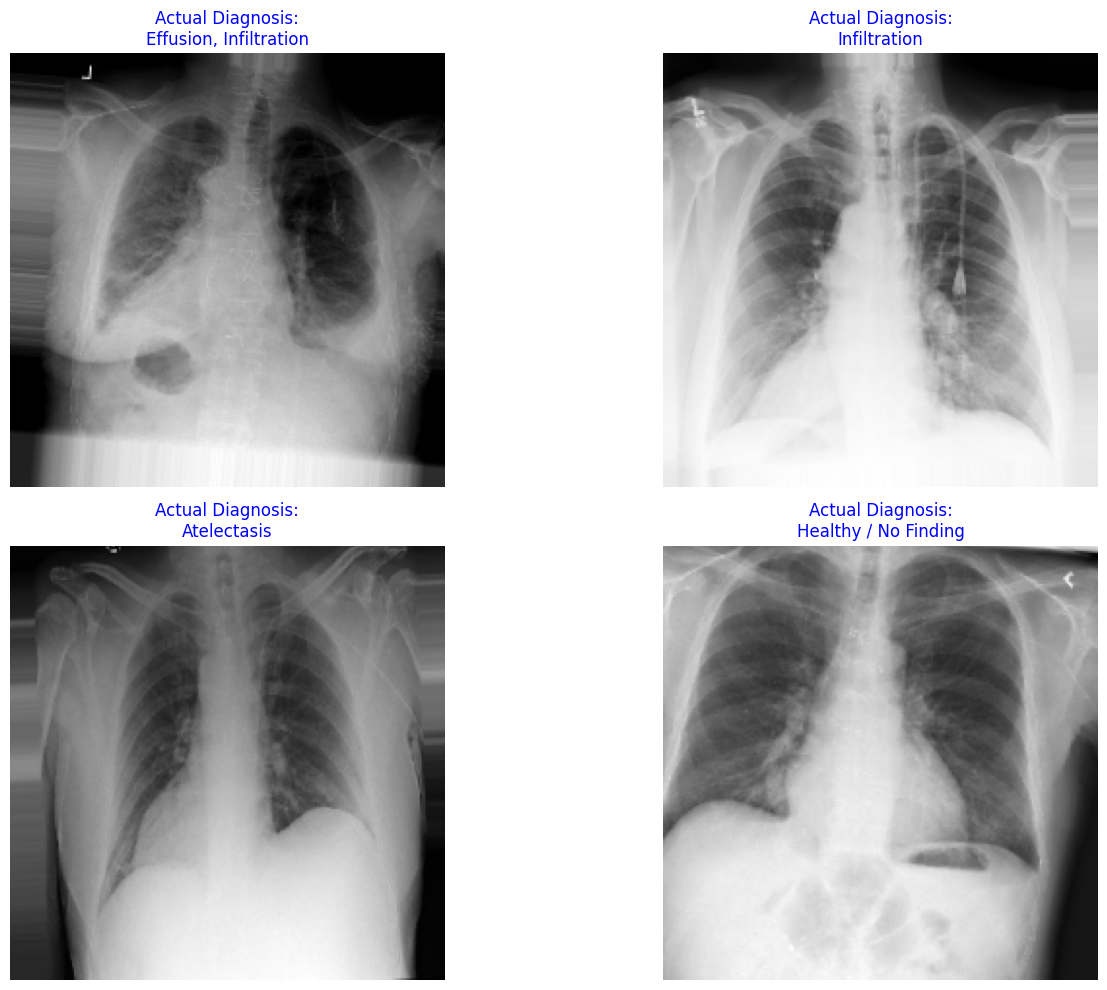

In [18]:
# Fetch a batch of images and labels from the generator
t_x, t_y = next(train_gen)

plt.figure(figsize=(15, 10))
for i in range(4): # Display 4 sample images
    plt.subplot(2, 2, i+1)
    
    # Normalize image for display purposes
    img = (t_x[i] - t_x[i].min()) / (t_x[i].max() - t_x[i].min())
    plt.imshow(img)
    
    # Map indices back to actual disease names
    # np.where(t_y[i] == 1)[0] finds the indices, then we look them up in LABEL_COLUMNS
    indices = np.where(t_y[i] == 1)[0]
    active_labels = [LABEL_COLUMNS[idx] for idx in indices]
    
    # If no labels are active, it's a 'No Finding' case
    title_text = ", ".join(active_labels) if active_labels else "Healthy / No Finding"
    
    plt.title(f"Actual Diagnosis:\n{title_text}", fontsize=12, color='blue')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [19]:

# 2. Callbacks
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_auc', verbose=1, save_best_only=True, mode='max')
early_stopping = EarlyStopping(monitor='val_auc', patience=5, mode='max', restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1)

# 3. Fit Model
history = model.fit(
    train_gen,
    steps_per_epoch=len(train_gen),
    validation_data=valid_gen,
    validation_steps=len(valid_gen),
    epochs=20,
    callbacks=[checkpoint, early_stopping, reduce_lr]
)

Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 927ms/step - auc: 0.5631 - binary_accuracy: 0.6393 - loss: 0.6614
Epoch 1: val_auc improved from -inf to 0.67880, saving model to best_model.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1113s 1s/step - auc: 0.5631 - binary_accuracy: 0.6394 - loss: 0.6612 - val_auc: 0.6788 - val_binary_accuracy: 0.8816 - val_loss: 0.3624 - learning_rate: 1.0000e-04
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 743ms/step - auc: 0.6454 - binary_accuracy: 0.8816 - loss: 0.3426
Epoch 2: val_auc improved from 0.67880 to 0.73573, saving model to best_model.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 865s 865ms/step - auc: 0.6454 - binary_accuracy: 0.8816 - loss: 0.3426 - val_auc: 0.7357 - val_binary_accuracy: 0.8839 - val_loss: 0.2965 - learning_rate: 1.0000e-04
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 736ms/step - auc: 0.7211 - binary_accuracy: 0.8855 - loss: 0.2938
Epoch 3: val_auc improved from 0.73573 to 0.75798, saving model to best_model.keras
1000/1000 ━━━━━━━━━━━━━━━━

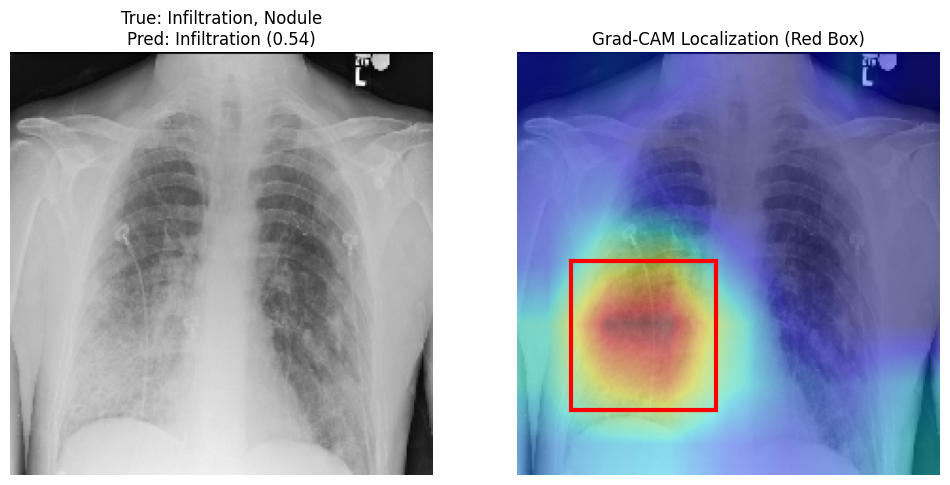

In [31]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

# 1. Setup the Grad-CAM model based on our trained architecture
def get_grad_model(trained_model):
    # Get the last convolutional layer of DenseNet121
    # In Keras implementation of DenseNet121, it's usually named 'relu' or 'conv5_block16_concat'
    # We will find it dynamically
    last_conv_layer = None
    for layer in reversed(trained_model.layers):
        if isinstance(layer, tf.keras.layers.Concatenate) or "conv" in layer.name:
            last_conv_layer = layer
            break
            
    return tf.keras.models.Model(
        inputs=[trained_model.inputs], 
        outputs=[last_conv_layer.output, trained_model.output]
    )

grad_model = get_grad_model(model)

# 2. Function to generate heatmap and bounding box
def visualize_prediction(img_idx, generator):
    # Get image and true labels
    images, labels = generator[img_idx // BATCH_SIZE]
    img = images[img_idx % BATCH_SIZE]
    true_label_indices = np.where(labels[img_idx % BATCH_SIZE] == 1)[0]
    true_labels_str = ", ".join([LABEL_COLUMNS[i] for i in true_label_indices]) if len(true_label_indices) > 0 else "Healthy"
    
    img_tensor = np.expand_dims(img, axis=0)
    
    # Get gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        # Focus on the highest probability class
        top_class_idx = np.argmax(predictions[0])
        loss = predictions[:, top_class_idx]

    # Calculate gradients of the top predicted class with respect to the output feature map
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Weight the channels by the gradient importance
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Post-process heatmap
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    heatmap = heatmap.numpy()
    
    # Upsample heatmap to image size
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE[0], IMG_SIZE[1]))
    
    # Generate Bounding Box from Heatmap (thresholding)
    # We take areas with more than 60% intensity
    thresh = (heatmap_resized > 0.6).astype(np.uint8)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Plotting
    plt.figure(figsize=(12, 6))
    
    # Original Image
    plt.subplot(1, 2, 1)
    display_img = (img - img.min()) / (img.max() - img.min())
    plt.imshow(display_img)
    plt.title(f"True: {true_labels_str}\nPred: {LABEL_COLUMNS[top_class_idx]} ({predictions[0][top_class_idx]:.2f})")
    plt.axis('off')
    
    # Heatmap + BBox
    plt.subplot(1, 2, 2)
    plt.imshow(display_img)
    plt.imshow(heatmap_resized, alpha=0.4, cmap='jet')
    
    if contours:
        # Find the largest contour (main disease area)
        largest_cnt = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_cnt)
        rect = plt.Rectangle((x, y), w, h, linewidth=3, edgecolor='red', facecolor='none')
        plt.gca().add_patch(rect)
        
    plt.title("Grad-CAM Localization (Red Box)")
    plt.axis('off')
    plt.show()

# Test it on a random sample from validation
visualize_prediction(550, valid_gen)